# Venue Homes -> Ward-Level Areal Interpolation

Pipeline:

1. Load `venues_homes.csv` and join venue coordinates from `venues-centroids.geojson` (on `id` <-> `venue_id`)
2. Decode `home_geohash6` to a centroid lat/lon
3. Build a grid GeoDataFrame: one polygon per venue's home geohash-6 cell, keeping all venue fields
4. Load `city-wards.geojson`
5. **Areal-weighted interpolation**: split each geohash-6 cell's `normalized_raw_stop_count`
   across whichever wards it overlaps, proportional to the overlap area, then sum per
   `(venue_id, ward)` -- this gives one row per venue per ward
6. Flag `home_ward = True` on the one row per venue where that venue's own point actually
   falls inside that ward's polygon, and attach that venue's ward as `venue_ward` on every row
7. Roll the venue-level result up two different ways: by venue (`ward_to_venue_*`) and by
   the venue's own ward, i.e. ward-to-ward (`ward_to_ward_*`)

Requirements: `pandas`, `geopandas`, `shapely`, `pygeohash`
(`pip install pandas geopandas shapely pygeohash`)

## Outputs (all written to `data/activity/wards/`)

Every visit has two wards attached to it: the **origin** ward (`ward_name`, decoded from the
visitor's home geohash cell) and the **destination** ward (`venue_ward`, the ward the venue
itself sits in). The four files below are all just different levels of aggregation over that
same underlying (origin, destination) flow:

| file | grain | analogous to |
|---|---|---|
| `ward_to_venue_activity` | (venue, origin ward) | -- |
| `ward_to_venue_summary` | venue, in vs. out of its own ward | `ward_to_venue_activity` rolled up per venue |
| `ward_to_ward_activity` | (origin ward, destination ward) | `ward_to_venue_activity`, but destination is a ward instead of a venue |
| `ward_to_ward_summary` | origin ward, in vs. out of itself | `ward_to_ward_activity` rolled up per origin ward (= old `ward_to_ward_activity`) |


In [1]:
# CELL 1 -- Imports

import os

import pandas as pd
import geopandas as gpd
import pygeohash as pgh
from shapely.geometry import box
from shapely.ops import unary_union
from tqdm import tqdm

import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_theme(style="whitegrid", rc={"figure.figsize": (7, 4)})

## 0. Config

In [2]:
# CELL 2 -- Constants

# ---- file paths (input) ----
VENUES_HOMES_CSV = "../../data/activity/venues_homes.csv"
VENUE_CENTROIDS_GEOJSON = "../../data/venues/tac-list/venues-centroids.geojson"
WARDS_GEOJSON = "../../data/geo/city-wards.geojson"

# ---- file paths (output) -- all ward-level exports live together here, so the four
# files (venue-grain and ward-grain, full breakdown and in/out summary) are easy to find
# and compare side by side ----
WARDS_OUTPUT_DIR = "../../data/activity/wards"
WARD_TO_VENUE_ACTIVITY_CSV = f"{WARDS_OUTPUT_DIR}/ward_to_venue_activity.csv"
WARD_TO_VENUE_ACTIVITY_JSON = f"{WARDS_OUTPUT_DIR}/ward_to_venue_activity.json"
WARD_TO_VENUE_SUMMARY_CSV = f"{WARDS_OUTPUT_DIR}/ward_to_venue_summary.csv"
WARD_TO_VENUE_SUMMARY_JSON = f"{WARDS_OUTPUT_DIR}/ward_to_venue_summary.json"
WARD_TO_WARD_ACTIVITY_CSV = f"{WARDS_OUTPUT_DIR}/ward_to_ward_activity.csv"
WARD_TO_WARD_ACTIVITY_JSON = f"{WARDS_OUTPUT_DIR}/ward_to_ward_activity.json"
WARD_TO_WARD_MATRIX_CSV = f"{WARDS_OUTPUT_DIR}/ward_to_ward_matrix.csv"
WARD_TO_WARD_SUMMARY_CSV = f"{WARDS_OUTPUT_DIR}/ward_to_ward_summary.csv"
WARD_TO_WARD_SUMMARY_JSON = f"{WARDS_OUTPUT_DIR}/ward_to_ward_summary.json"
WARD_BREAKDOWN_DIR = f"{WARDS_OUTPUT_DIR}/by_origin_ward"  # one CSV per origin ward -- see section 10b

# ---- column names -- ADJUST if your files use different field names ----
VENUE_ID_COL = "venue_id"                        # id column in venues_homes.csv
CENTROID_ID_COL = "id"                           # id column in venues-centroids.geojson
VENUE_NAME_COL = "venue_name"                    # name column in venues-centroids.geojson (if present)
WARD_NAME_COL = "ward_name"                      # name column in city-wards.geojson; used here as the ORIGIN ward (where visitors' homes are)
DEST_WARD_COL = "venue_ward"                     # the DESTINATION ward -- the ward the venue itself is physically located in
VALUE_COL = "normalized_raw_stop_count"          # value column in venues_homes.csv to interpolate
GEOHASH_COL = "home_geohash6"

# venues_homes.csv contains OVERLAPPING time-period breakdowns of the same activity
# (e.g. "all" = "weekdays" + "weekends", and "nine-five"/"evening" are a separate,
# overlapping time-of-day partition) -- summing every row double/triple counts the same
# underlying activity, so exactly one time_period must be selected before anything else runs
TIME_PERIOD_COL = "time_period"
TIME_PERIOD_VALUE = "all"                        # the period to analyze -- change if you want e.g. "weekdays" instead

RESULT_COL = f"{VALUE_COL}_by_ward"              # name of the interpolated output column

os.makedirs(WARDS_OUTPUT_DIR, exist_ok=True)
os.makedirs(WARD_BREAKDOWN_DIR, exist_ok=True)

## 1. Load venues_homes.csv and join venue coordinates

In [3]:
venues_homes = pd.read_csv(VENUES_HOMES_CSV)
print("venues_homes columns:", venues_homes.columns.tolist())

if TIME_PERIOD_COL in venues_homes.columns:
    print("time_period value counts:")
    print(venues_homes[TIME_PERIOD_COL].value_counts())

    _n_before = len(venues_homes)
    venues_homes = venues_homes[venues_homes[TIME_PERIOD_COL] == TIME_PERIOD_VALUE].reset_index(drop=True)
    print(f"Filtered to {TIME_PERIOD_COL} == '{TIME_PERIOD_VALUE}': {_n_before} -> {len(venues_homes)} rows.")
else:
    print(f"Note: '{TIME_PERIOD_COL}' not found -- skipping time-period filter.")

# duplicate-row check -- an exact duplicate row (or a repeated venue_id+home_geohash6 pair)
# means that value gets counted twice from the very start, before any geo logic runs
n_exact_dupes = int(venues_homes.duplicated().sum())
n_key_dupes = int(venues_homes.duplicated(subset=[VENUE_ID_COL, GEOHASH_COL]).sum())
if n_exact_dupes:
    print(f"WARNING: {n_exact_dupes} fully duplicate row(s) in venues_homes.csv.")
if n_key_dupes:
    print(f"WARNING: {n_key_dupes} row(s) share the same (venue_id, home_geohash6) pair -- check for duplicate exports.")

venues_homes.head()


venues_homes columns: ['home_geohash6', 'venue_id', 'venue_name', 'time_period', 'raw_stop_count', 'visit_count', 'unique_devices', 'normalized_raw_stop_count', 'normalized_visit_count', 'normalized_unique_device_months']
time_period value counts:
time_period
all          14745
weekdays     12262
nine-five     7623
evening       7565
weekends      7062
Name: count, dtype: int64
Filtered to time_period == 'all': 49257 -> 14745 rows.


,home_geohash6,venue_id,venue_name,time_period,raw_stop_count,visit_count,unique_devices,normalized_raw_stop_count,normalized_visit_count,normalized_unique_device_months
0,dpz2jc,1,InterAccess,all,2,2,2,1.324172,1.324172,1.324172
1,dpz2jf,1,InterAccess,all,2,2,2,1.531940,1.531940,1.531940
2,dpz2mt,1,InterAccess,all,1,1,1,0.583720,0.583720,0.583720
3,dpz2mx,1,InterAccess,all,1,1,1,0.714649,0.714649,0.714649
4,dpz2nh,1,InterAccess,all,4,4,2,2.364828,2.364828,1.151578


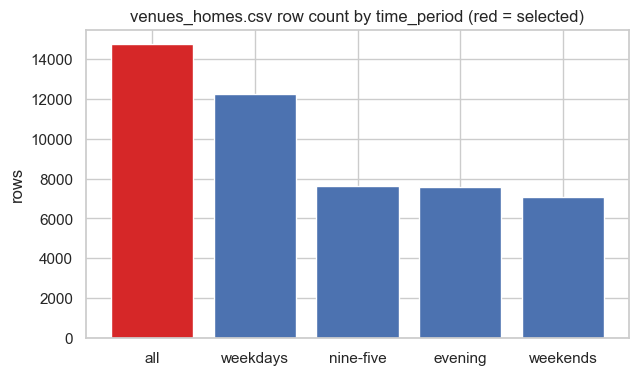

In [4]:
# viz: row counts by time_period, straight from the raw file (self-contained, before
# any filtering) -- a visual reminder that "all" isn't just another slice like the rest,
# it's the sum of them, which is *why* we have to pick exactly one before summing anything
_tp_counts = pd.read_csv(VENUES_HOMES_CSV)[TIME_PERIOD_COL].value_counts()

fig, ax = plt.subplots()
colors = ["#d62728" if tp == TIME_PERIOD_VALUE else "#4c72b0" for tp in _tp_counts.index]
ax.bar(_tp_counts.index, _tp_counts.values, color=colors)
ax.set_title("venues_homes.csv row count by time_period (red = selected)")
ax.set_ylabel("rows")
plt.show()

In [5]:
venue_centroids = gpd.read_file(VENUE_CENTROIDS_GEOJSON)
print("venue_centroids columns:", venue_centroids.columns.tolist())

# extract lat/lon from the point geometry
venue_centroids["venue_lon"] = venue_centroids.geometry.x
venue_centroids["venue_lat"] = venue_centroids.geometry.y

# make sure both join keys are the same dtype/format before merging
# (e.g. one side stored as int, the other as string -- this normalizes both to stripped strings)
venues_homes[VENUE_ID_COL] = venues_homes[VENUE_ID_COL].astype(str).str.strip()
venue_centroids[CENTROID_ID_COL] = venue_centroids[CENTROID_ID_COL].astype(str).str.strip()

# duplicate-id check -- if venue_centroids has more than one row for the same id, the
# merge below fans out: every one of that venue's rows gets duplicated once per match,
# silently inflating every downstream sum for that venue (and whichever ward it's in)
n_dup_centroid_ids = int(venue_centroids[CENTROID_ID_COL].duplicated().sum())
if n_dup_centroid_ids:
    dup_ids = venue_centroids.loc[venue_centroids[CENTROID_ID_COL].duplicated(keep=False), CENTROID_ID_COL].unique()
    print(f"WARNING: {n_dup_centroid_ids} duplicate id(s) in venue_centroids -- this WILL fan out the merge below. Affected id(s): {list(dup_ids)[:10]}")

join_cols = [CENTROID_ID_COL, "venue_lat", "venue_lon"]
if VENUE_NAME_COL in venue_centroids.columns:
    join_cols.append(VENUE_NAME_COL)
else:
    print(f"Note: '{VENUE_NAME_COL}' not found in venue_centroids -- skipping venue name join.")

_pre_merge_rows = len(venues_homes)
_pre_merge_value_sum = venues_homes[VALUE_COL].sum()

venues_homes = venues_homes.merge(
    venue_centroids[join_cols],
    left_on=VENUE_ID_COL, right_on=CENTROID_ID_COL, how="left",
).drop(columns=[CENTROID_ID_COL])

n_missing = venues_homes["venue_lat"].isna().sum()
if n_missing:
    print(f"Warning: {n_missing} venues_homes rows did not match a centroid record on id.")

# fan-out check -- this merge should only ADD columns, never rows or value. If either
# changed, some id matched more than once on the centroids side (see the duplicate-id
# check above) and every downstream number for that venue is now inflated.
_post_merge_rows = len(venues_homes)
_post_merge_value_sum = venues_homes[VALUE_COL].sum()
if _post_merge_rows != _pre_merge_rows or not abs(_post_merge_value_sum - _pre_merge_value_sum) < 1e-6:
    print(f"WARNING: merge changed row count ({_pre_merge_rows} -> {_post_merge_rows}) and/or "
          f"{VALUE_COL} sum ({_pre_merge_value_sum:,.3f} -> {_post_merge_value_sum:,.3f}). "
          f"This means the join fanned out -- fix duplicate ids in venue_centroids before trusting any result below.")
else:
    print(f"Merge OK: row count and {VALUE_COL} sum unchanged ({_post_merge_rows} rows, sum {_post_merge_value_sum:,.3f}).")

venues_homes.head()


Skipping field disciplines_supported: unsupported OGR type: 5


venue_centroids columns: ['fid', 'venue_name', 'address', 'postal_code', 'max_attendee_capacity', 'total_facility_area_sqft', 'primary_discipline', 'ownership', 'operator', 'tac_funded_operator', 'tac_funded_resident', 'tac_funded_programming', 'year_opened', 'venue_description', 'owner', 'id', 'geometry']
Merge OK: row count and normalized_raw_stop_count sum unchanged (14745 rows, sum 116,008.002).


,home_geohash6,venue_id,venue_name_x,time_period,raw_stop_count,visit_count,unique_devices,normalized_raw_stop_count,normalized_visit_count,normalized_unique_device_months,venue_lat,venue_lon,venue_name_y
0,dpz2jc,1,InterAccess,all,2,2,2,1.324172,1.324172,1.324172,43.641945,-79.423363,InterAccess
1,dpz2jf,1,InterAccess,all,2,2,2,1.531940,1.531940,1.531940,43.641945,-79.423363,InterAccess
2,dpz2mt,1,InterAccess,all,1,1,1,0.583720,0.583720,0.583720,43.641945,-79.423363,InterAccess
3,dpz2mx,1,InterAccess,all,1,1,1,0.714649,0.714649,0.714649,43.641945,-79.423363,InterAccess
4,dpz2nh,1,InterAccess,all,4,4,2,2.364828,2.364828,1.151578,43.641945,-79.423363,InterAccess


## 2. Decode home_geohash6 centroid coordinates

In [6]:
venues_homes[GEOHASH_COL] = venues_homes[GEOHASH_COL].astype(str).str.strip().str.lower()

def safe_decode(gh):
    try:
        lat, lon = pgh.decode(gh)
        return pd.Series({"home_geohash6_lat": lat, "home_geohash6_lon": lon})
    except Exception:
        return pd.Series({"home_geohash6_lat": None, "home_geohash6_lon": None})

venues_homes[["home_geohash6_lat", "home_geohash6_lon"]] = venues_homes[GEOHASH_COL].apply(safe_decode)
venues_homes.head()


,home_geohash6,venue_id,venue_name_x,time_period,raw_stop_count,visit_count,unique_devices,normalized_raw_stop_count,normalized_visit_count,normalized_unique_device_months,venue_lat,venue_lon,venue_name_y,home_geohash6_lat,home_geohash6_lon
0,dpz2jc,1,InterAccess,all,2,2,2,1.324172,1.324172,1.324172,43.641945,-79.423363,InterAccess,43.601990,-79.546509
1,dpz2jf,1,InterAccess,all,2,2,2,1.531940,1.531940,1.531940,43.641945,-79.423363,InterAccess,43.607483,-79.546509
2,dpz2mt,1,InterAccess,all,1,1,1,0.583720,0.583720,0.583720,43.641945,-79.423363,InterAccess,43.667908,-79.557495
3,dpz2mx,1,InterAccess,all,1,1,1,0.714649,0.714649,0.714649,43.641945,-79.423363,InterAccess,43.678894,-79.557495
4,dpz2nh,1,InterAccess,all,4,4,2,2.364828,2.364828,1.151578,43.641945,-79.423363,InterAccess,43.618469,-79.535522


## 3. Build the grid GeoDataFrame (one polygon per venue's home cell)

Unlike a deduplicated grid, this keeps **one row per venue** (with its full set of fields),
because the interpolation step below needs a per-venue value, not a per-cell aggregate. If
two venues share the same geohash-6 cell, they'll get identical (overlapping) polygons -- that's
expected here.


In [7]:
def geohash_to_polygon(gh):
    """True bounding-box polygon of a geohash string, using its exact error margins."""
    lat_c, lon_c, lat_err, lon_err = pgh.decode_exactly(gh)
    return box(lon_c - lon_err, lat_c - lat_err, lon_c + lon_err, lat_c + lat_err)

grid_gdf = venues_homes.copy()
grid_gdf["geometry"] = grid_gdf[GEOHASH_COL].apply(geohash_to_polygon)
grid_gdf = gpd.GeoDataFrame(grid_gdf, geometry="geometry", crs="EPSG:4326")

print(f"grid_gdf: {len(grid_gdf)} rows (one per venue)")
grid_gdf.head()


grid_gdf: 14745 rows (one per venue)


,home_geohash6,venue_id,venue_name_x,time_period,raw_stop_count,visit_count,unique_devices,normalized_raw_stop_count,normalized_visit_count,normalized_unique_device_months,venue_lat,venue_lon,venue_name_y,home_geohash6_lat,home_geohash6_lon,geometry
0,dpz2jc,1,InterAccess,all,2,2,2,1.324172,1.324172,1.324172,43.641945,-79.423363,InterAccess,43.601990,-79.546509,"POLYGON ((-79.54102 43.59924, -79.54102 43.604..."
1,dpz2jf,1,InterAccess,all,2,2,2,1.531940,1.531940,1.531940,43.641945,-79.423363,InterAccess,43.607483,-79.546509,"POLYGON ((-79.54102 43.60474, -79.54102 43.610..."
2,dpz2mt,1,InterAccess,all,1,1,1,0.583720,0.583720,0.583720,43.641945,-79.423363,InterAccess,43.667908,-79.557495,"POLYGON ((-79.552 43.66516, -79.552 43.67065, ..."
3,dpz2mx,1,InterAccess,all,1,1,1,0.714649,0.714649,0.714649,43.641945,-79.423363,InterAccess,43.678894,-79.557495,"POLYGON ((-79.552 43.67615, -79.552 43.68164, ..."
4,dpz2nh,1,InterAccess,all,4,4,2,2.364828,2.364828,1.151578,43.641945,-79.423363,InterAccess,43.618469,-79.535522,"POLYGON ((-79.53003 43.61572, -79.53003 43.621..."


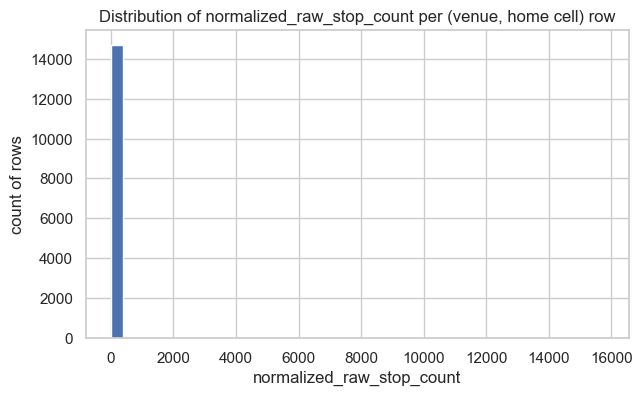

In [8]:
# viz: distribution of activity per home cell -- highly right-skewed (most home cells
# contribute a handful of stops; a few contribute a lot), which is worth keeping in mind
# since areal interpolation spreads each cell's value uniformly across the wards it
# overlaps -- a few outsized cells straddling a ward boundary can move a lot of "weight"
fig, ax = plt.subplots()
ax.hist(grid_gdf[VALUE_COL], bins=40, color="#4c72b0")
ax.set_title(f"Distribution of {VALUE_COL} per (venue, home cell) row")
ax.set_xlabel(VALUE_COL)
ax.set_ylabel("count of rows")
plt.show()

## 4. Load ward polygons

Real-world ward/boundary files often carry a stray non-polygon row (a boundary-line artifact,
a label point) or an invalid self-intersecting polygon. Both will make `geopandas.overlay`
fail later with `NotImplementedError: ... contains mixed geometry types`, so this is cleaned
up once here, immediately after loading, so every downstream step (the cross-join, the
interpolation, the `home_ward` spatial join) sees a consistent, pure-polygon `wards_gdf`.


In [9]:
def keep_polygons_only(gdf, label="layer"):
    """Repair invalid geometries and drop/collapse anything that isn't a polygon,
    so downstream steps (overlay, cross-joins, spatial joins) never see a mixed-type layer."""
    gdf = gdf.copy()
    gdf = gdf[gdf.geometry.notna() & ~gdf.geometry.is_empty]

    types_before = gdf.geometry.geom_type.value_counts().to_dict()
    if len(types_before) > 1 or not set(types_before) <= {"Polygon", "MultiPolygon"}:
        print(f"{label}: geometry types found -> {types_before}")

    gdf["geometry"] = gdf.geometry.make_valid()

    def polys_only(geom):
        if geom is None or geom.is_empty:
            return None
        if geom.geom_type in ("Polygon", "MultiPolygon"):
            return geom
        if geom.geom_type == "GeometryCollection":
            polys = [g for g in geom.geoms if g.geom_type in ("Polygon", "MultiPolygon")]
            if not polys:
                return None
            return polys[0] if len(polys) == 1 else unary_union(polys)
        return None  # drop stray points/lines entirely

    gdf["geometry"] = gdf["geometry"].apply(polys_only)
    n_dropped = int(gdf["geometry"].isna().sum())
    if n_dropped:
        print(f"{label}: dropped {n_dropped} non-polygonal row(s) after cleaning")

    return gdf[gdf["geometry"].notna()].reset_index(drop=True)


wards_gdf = gpd.read_file(WARDS_GEOJSON)
print("wards columns:", wards_gdf.columns.tolist())

if wards_gdf.crs is None:
    wards_gdf = wards_gdf.set_crs("EPSG:4326")
else:
    wards_gdf = wards_gdf.to_crs("EPSG:4326")

wards_gdf = keep_polygons_only(wards_gdf, "wards")

# ward-overlap check -- areal interpolation assumes wards tile the area with NO overlap.
# if two ward polygons overlap each other, a single grid cell can get counted as area in
# both, inflating both wards' totals. sum-of-individual-areas > union-area signals this.
_wards_check = wards_gdf.to_crs(wards_gdf.estimate_utm_crs())
_sum_individual_area = _wards_check.geometry.area.sum()
_union_area = _wards_check.geometry.union_all().area
_overlap_area = _sum_individual_area - _union_area
_overlap_pct = (_overlap_area / _sum_individual_area) if _sum_individual_area else 0.0
print(f"Ward overlap check: sum of individual areas = {_sum_individual_area:,.1f} m^2, "
      f"union area = {_union_area:,.1f} m^2, overlap = {_overlap_area:,.1f} m^2 ({_overlap_pct:.2%})")
if _overlap_area > 1:  # more than trivial floating-point noise
    print("WARNING: ward polygons overlap each other -- this can inflate ward-level totals downstream.")

wards_gdf.head()

wards columns: ['ward_code', 'ward_name', 'geometry']


wards: geometry types found -> {'MultiPolygon': 25, 'MultiLineString': 21, 'LineString': 4}
wards: dropped 25 non-polygonal row(s) after cleaning
Ward overlap check: sum of individual areas = 642,522,585.5 m^2, union area = 642,522,585.2 m^2, overlap = 0.4 m^2 (0.00%)


,ward_code,ward_name,geometry
0,07,Humber River-Black Creek,"MULTIPOLYGON (((-79.49105 43.7635, -79.49008 4..."
1,06,York Centre,"MULTIPOLYGON (((-79.44043 43.7634, -79.43998 4..."
2,18,Willowdale,"MULTIPOLYGON (((-79.39449 43.76157, -79.39461 ..."
3,11,University-Rosedale,"MULTIPOLYGON (((-79.39004 43.6905, -79.39004 4..."
4,19,Beaches-East York,"MULTIPOLYGON (((-79.29864 43.71515, -79.29837 ..."


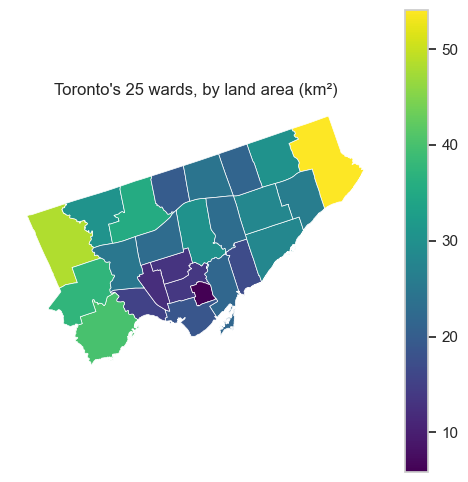

In [10]:
# viz: the 25 wards, colored by land area -- wards vary a lot in size (and therefore in
# how much a single geohash-6 cell's area-weighted split matters), which is useful context
# for anything downstream that treats "one ward" as a comparable unit
_wards_area = wards_gdf.to_crs(wards_gdf.estimate_utm_crs())
_wards_area["area_km2"] = _wards_area.geometry.area / 1e6

fig, ax = plt.subplots(figsize=(6, 6))
_wards_area.plot(column="area_km2", cmap="viridis", legend=True, edgecolor="white", linewidth=0.5, ax=ax)
ax.set_title("Toronto's 25 wards, by land area (km²)")
ax.set_axis_off()
plt.show()

## 5. Areal-weighted interpolation: geohash cell -> ward

For each venue's home cell, split `normalized_raw_stop_count` across the wards it overlaps,
in proportion to the fraction of the cell's area that falls in each ward. This is standard
areal weighting (assumes the value is spread uniformly within the source cell).

Steps:
1. Reproject to a local projected CRS (so area calculations are accurate in meters, not degrees)
2. Overlay the grid cells with the (already-cleaned) ward polygons to get the intersection pieces
3. `weight = piece_area / original_cell_area`
4. `interpolated_value = weight * normalized_raw_stop_count`
5. Sum by `(venue_id, ward)` -- a cell can rarely produce more than one piece in the same ward
   (e.g. an irregular ward boundary), so this collapses those back together


In [11]:
# reproject both layers to an accurate local CRS for area math
proj_crs = grid_gdf.estimate_utm_crs()
grid_proj = grid_gdf.to_crs(proj_crs)
wards_proj = wards_gdf.to_crs(proj_crs)

# slim the grid down before the overlay to avoid column name collisions with ward attributes,
# and run it through the same polygon-only cleaning as a safety net
grid_slim = grid_proj[[VENUE_ID_COL, VALUE_COL, "geometry"]].copy()
grid_slim["source_area"] = grid_slim.geometry.area
grid_slim = keep_polygons_only(grid_slim, "grid")

pieces = gpd.overlay(
    grid_slim,
    wards_proj[[WARD_NAME_COL, "geometry"]],
    how="intersection",
    keep_geom_type=True,
)

pieces["piece_area"] = pieces.geometry.area
pieces["area_weight"] = pieces["piece_area"] / pieces["source_area"]
pieces["interpolated_value"] = pieces["area_weight"] * pieces[VALUE_COL]

ward_venue_agg = (
    pieces.groupby([VENUE_ID_COL, WARD_NAME_COL], as_index=False)["interpolated_value"].sum()
    .rename(columns={"interpolated_value": RESULT_COL})
)

ward_venue_agg.head()


,venue_id,ward_name,normalized_raw_stop_count_by_ward
0,1,Beaches-East York,6.604701
1,1,Davenport,193.902512
2,1,Don Valley East,6.669742
3,1,Don Valley North,11.999412
4,1,Don Valley West,6.102152


## 6. Ensure every venue has a row for every ward (fill 0 where there's no overlap)


In [12]:
all_venues = grid_gdf[VENUE_ID_COL].unique()
all_wards = wards_gdf[WARD_NAME_COL].unique()

full_index = pd.MultiIndex.from_product([all_venues, all_wards], names=[VENUE_ID_COL, WARD_NAME_COL])
result = pd.DataFrame(index=full_index).reset_index()
result = result.merge(ward_venue_agg, on=[VENUE_ID_COL, WARD_NAME_COL], how="left")
result[RESULT_COL] = result[RESULT_COL].fillna(0.0)

print(f"rows: {len(result)}  (should be {len(all_venues)} venues x {len(all_wards)} wards = {len(all_venues) * len(all_wards)})")

# sanity check: per venue, the interpolated pieces should sum back to ~ the original value.
check = result.groupby(VENUE_ID_COL)[RESULT_COL].sum()

# sum (not drop_duplicates) -- a venue can have multiple home geohash-6 rows (multiple
# visitors' homes all landing at the same venue), so the correct "original total" is the
# sum across all of that venue's home cells, matching how `check` above is summed.
orig = grid_gdf.groupby(VENUE_ID_COL)[VALUE_COL].sum()

# keep the SIGN here -- negative means undercounted (cell not fully covered by wards),
# positive means OVERcounted (a strong signal of overlapping ward polygons -- see the
# overlap check above), and .abs() alone can't distinguish the two
reconstruction_diff_signed = check - orig
max_abs_diff = reconstruction_diff_signed.abs().max()
print(f"Max reconstruction diff (0 = no under/over counting): {max_abs_diff}")
if max_abs_diff > 1e-6:
    n_under = int((reconstruction_diff_signed < -1e-6).sum())
    n_over = int((reconstruction_diff_signed > 1e-6).sum())
    print(f"  -> {n_under} venue(s) UNDER-counted (home cell not fully covered by the wards layer)")
    print(f"  -> {n_over} venue(s) OVER-counted (check the ward-overlap warning above)")


rows: 2625  (should be 105 venues x 25 wards = 2625)
Max reconstruction diff (0 = no under/over counting): 349.8427368574048
  -> 96 venue(s) UNDER-counted (home cell not fully covered by the wards layer)
  -> 0 venue(s) OVER-counted (check the ward-overlap warning above)


## 7. Attach venue attributes and select final columns

In [13]:
venue_attrs = venues_homes.drop_duplicates(VENUE_ID_COL).set_index(VENUE_ID_COL)

attr_cols = ["venue_lat", "venue_lon"]
if VENUE_NAME_COL in venue_attrs.columns:
    attr_cols.append(VENUE_NAME_COL)

result = result.merge(venue_attrs[attr_cols], left_on=VENUE_ID_COL, right_index=True, how="left")

final_cols = [VENUE_ID_COL]
if VENUE_NAME_COL in result.columns:
    final_cols.append(VENUE_NAME_COL)
final_cols += ["venue_lat", "venue_lon", WARD_NAME_COL, RESULT_COL]

result = result[final_cols]
result.head(20)


,venue_id,venue_lat,venue_lon,ward_name,normalized_raw_stop_count_by_ward
0,1,43.641945,-79.423363,Humber River-Black Creek,7.591310
1,1,43.641945,-79.423363,York Centre,7.543805
2,1,43.641945,-79.423363,Willowdale,3.757519
3,1,43.641945,-79.423363,University-Rosedale,42.726933
4,1,43.641945,-79.423363,Beaches-East York,6.604701
5,1,43.641945,-79.423363,Scarborough Southwest,5.525621
6,1,43.641945,-79.423363,Scarborough-Rouge Park,12.738668
7,1,43.641945,-79.423363,Scarborough North,1.851775
8,1,43.641945,-79.423363,Scarborough-Guildwood,6.354256
9,1,43.641945,-79.423363,Scarborough Centre,3.510001


## 8. `venue_ward` (destination) and `home_ward` flag

`venue_ward` is the ward the venue itself is physically located in -- found with a simple
point-in-polygon spatial join on the venue's own coordinate. `home_ward` is just the
convenience boolean `ward_name == venue_ward`, True on the one row per venue where the
*origin* ward (where visitors' homes are) matches the venue's own ward.

Keeping `venue_ward` (rather than discarding it once `home_ward` is computed) is what lets
section 10 below regroup `result` by destination ward instead of destination venue --
i.e. turn "visitors from ward X to venue Y" into "visitors from ward X to (any venue in)
ward Z".


In [14]:
venue_points_df = venue_attrs.reset_index()[[VENUE_ID_COL, "venue_lat", "venue_lon"]]
venue_points = gpd.GeoDataFrame(
    venue_points_df,
    geometry=gpd.points_from_xy(venue_points_df["venue_lon"], venue_points_df["venue_lat"]),
    crs="EPSG:4326",
)

venue_in_ward = gpd.sjoin(
    venue_points, wards_gdf[[WARD_NAME_COL, "geometry"]], how="left", predicate="within"
)[[VENUE_ID_COL, WARD_NAME_COL]].rename(columns={WARD_NAME_COL: DEST_WARD_COL})

result = result.merge(venue_in_ward, on=VENUE_ID_COL, how="left")
result["home_ward"] = result[WARD_NAME_COL] == result[DEST_WARD_COL]

n_venues_unmatched = result.groupby(VENUE_ID_COL)["home_ward"].any().eq(False).sum()
if n_venues_unmatched:
    print(f"Note: {n_venues_unmatched} venues did not fall inside any ward polygon (home_ward all False, {DEST_WARD_COL} all NaN).")

result.sort_values([VENUE_ID_COL, WARD_NAME_COL]).head(20)

,venue_id,venue_lat,venue_lon,ward_name,normalized_raw_stop_count_by_ward,venue_ward,home_ward
4,1,43.641945,-79.423363,Beaches-East York,6.604701,Davenport,False
20,1,43.641945,-79.423363,Davenport,193.902512,Davenport,True
19,1,43.641945,-79.423363,Don Valley East,6.669742,Davenport,False
18,1,43.641945,-79.423363,Don Valley North,11.999412,Davenport,False
11,1,43.641945,-79.423363,Don Valley West,6.102152,Davenport,False
17,1,43.641945,-79.423363,Eglinton-Lawrence,9.435344,Davenport,False
16,1,43.641945,-79.423363,Etobicoke Centre,4.088923,Davenport,False
14,1,43.641945,-79.423363,Etobicoke North,8.195479,Davenport,False
15,1,43.641945,-79.423363,Etobicoke-Lakeshore,9.337472,Davenport,False
0,1,43.641945,-79.423363,Humber River-Black Creek,7.591310,Davenport,False


## 8b. Attach venue_name directly from the raw CSV

Added as a final, standalone step: re-reads `venue_id -> venue_name` straight from
`venues_homes.csv` (rather than relying on `venue_name` surviving the earlier merges/joins
above -- e.g. if it got suffixed to `venue_name_x`/`venue_name_y` by a name collision with
another file upstream) and joins it onto `result` by `venue_id`. This is independent of
whatever happened to `venue_name` earlier in the notebook.


In [15]:
# pull a clean venue_id -> venue_name lookup directly from the source CSV
name_lookup = pd.read_csv(VENUES_HOMES_CSV)[[VENUE_ID_COL, VENUE_NAME_COL]].drop_duplicates(subset=VENUE_ID_COL)
name_lookup[VENUE_ID_COL] = name_lookup[VENUE_ID_COL].astype(str).str.strip()

# flag (don't silently hide) any venue_id that maps to more than one distinct name in the raw data
name_counts = pd.read_csv(VENUES_HOMES_CSV)[[VENUE_ID_COL, VENUE_NAME_COL]].drop_duplicates()
conflicts = name_counts.groupby(VENUE_ID_COL)[VENUE_NAME_COL].nunique()
conflicts = conflicts[conflicts > 1]
if len(conflicts):
    print(f"Warning: {len(conflicts)} venue_id(s) have more than one distinct venue_name in the raw CSV: {conflicts.index.tolist()}")

# make sure the join key matches dtype/format on both sides
result[VENUE_ID_COL] = result[VENUE_ID_COL].astype(str).str.strip()

# drop any stale venue_name-ish column left over from earlier steps, then join the clean one in
result = result.drop(columns=[c for c in result.columns if c.startswith(VENUE_NAME_COL)], errors="ignore")
result = result.merge(name_lookup, on=VENUE_ID_COL, how="left")

n_missing_name = result[VENUE_NAME_COL].isna().sum()
if n_missing_name:
    print(f"Warning: {n_missing_name} result rows did not get a venue_name (no matching venue_id in the CSV).")

# put venue_name right after venue_id for readability
cols = result.columns.tolist()
cols.remove(VENUE_NAME_COL)
cols.insert(cols.index(VENUE_ID_COL) + 1, VENUE_NAME_COL)
result = result[cols]

result.head()


,venue_id,venue_name,venue_lat,venue_lon,ward_name,normalized_raw_stop_count_by_ward,venue_ward,home_ward
0,1,InterAccess,43.641945,-79.423363,Humber River-Black Creek,7.591310,Davenport,False
1,1,InterAccess,43.641945,-79.423363,York Centre,7.543805,Davenport,False
2,1,InterAccess,43.641945,-79.423363,Willowdale,3.757519,Davenport,False
3,1,InterAccess,43.641945,-79.423363,University-Rosedale,42.726933,Davenport,False
4,1,InterAccess,43.641945,-79.423363,Beaches-East York,6.604701,Davenport,False


## 8c. Percent of each venue's total, by ward

Additional column on `result`: what share of a given venue's total interpolated stop count
came from each ward. This is a per-venue percentage (each venue's own rows sum to 100%),
not a share of any grand total across venues.


In [16]:
PCT_RESULT_COL = f"{RESULT_COL}_pct"

_venue_totals = result.groupby(VENUE_ID_COL)[RESULT_COL].transform("sum")
result[PCT_RESULT_COL] = (result[RESULT_COL] / _venue_totals).fillna(0.0)

# sanity check: each venue's percentages should sum to 1.0 (or 0.0 if that venue has zero total activity)
_pct_check = result.groupby(VENUE_ID_COL)[PCT_RESULT_COL].sum()
_bad = _pct_check[~_pct_check.round(6).isin([0.0, 1.0])]
if len(_bad):
    print(f"WARNING: {len(_bad)} venue(s) have per-venue percentages that don't sum to 0 or 1: {_bad.to_dict()}")

result.head(10)


,venue_id,venue_name,venue_lat,venue_lon,ward_name,normalized_raw_stop_count_by_ward,venue_ward,home_ward,normalized_raw_stop_count_by_ward_pct
0,1,InterAccess,43.641945,-79.423363,Humber River-Black Creek,7.591310,Davenport,False,0.007500
1,1,InterAccess,43.641945,-79.423363,York Centre,7.543805,Davenport,False,0.007453
2,1,InterAccess,43.641945,-79.423363,Willowdale,3.757519,Davenport,False,0.003712
3,1,InterAccess,43.641945,-79.423363,University-Rosedale,42.726933,Davenport,False,0.042215
4,1,InterAccess,43.641945,-79.423363,Beaches-East York,6.604701,Davenport,False,0.006526
5,1,InterAccess,43.641945,-79.423363,Scarborough Southwest,5.525621,Davenport,False,0.005459
6,1,InterAccess,43.641945,-79.423363,Scarborough-Rouge Park,12.738668,Davenport,False,0.012586
7,1,InterAccess,43.641945,-79.423363,Scarborough North,1.851775,Davenport,False,0.001830
8,1,InterAccess,43.641945,-79.423363,Scarborough-Guildwood,6.354256,Davenport,False,0.006278
9,1,InterAccess,43.641945,-79.423363,Scarborough Centre,3.510001,Davenport,False,0.003468


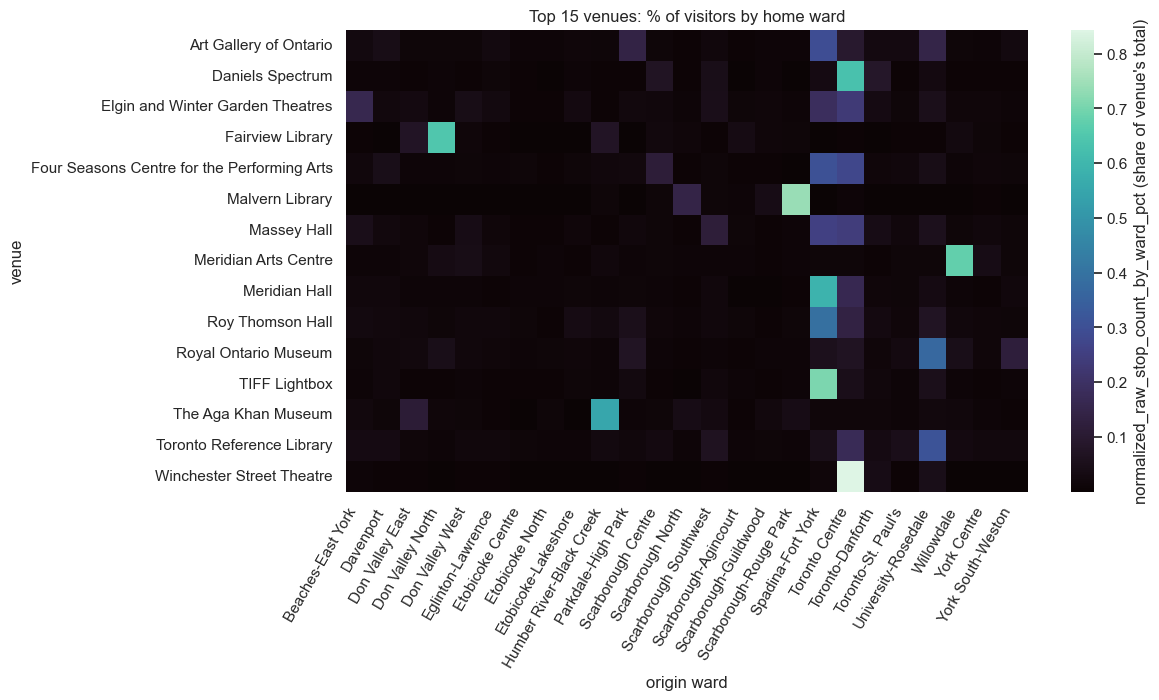

In [17]:
# viz: venue x ward draw pattern, top 15 venues by total activity -- some venues draw
# almost entirely from their own ward (a bright, narrow column), others draw fairly evenly
# from across the city (a diffuse row). Both patterns are "real" and worth distinguishing
# before treating venue-level activity as a stand-in for its ward's demographics.
_top_venues = result.groupby(VENUE_ID_COL)[RESULT_COL].sum().nlargest(15).index
_pivot = result[result[VENUE_ID_COL].isin(_top_venues)].pivot(
    index=VENUE_NAME_COL, columns=WARD_NAME_COL, values=PCT_RESULT_COL
)

fig, ax = plt.subplots(figsize=(11, 6))
sns.heatmap(_pivot, cmap="mako", cbar_kws={"label": f"{PCT_RESULT_COL} (share of venue's total)"}, ax=ax)
ax.set_title("Top 15 venues: % of visitors by home ward")
ax.set_xlabel("origin ward")
ax.set_ylabel("venue")
plt.xticks(rotation=60, ha="right")
plt.show()

## 9. Result: `ward_to_venue_activity`

`result` has one row per `(venue_id, ward_name)` combination, with:

- `venue_id`, `venue_name`, `venue_lat`, `venue_lon` -- the venue
- `ward_name` -- the ORIGIN ward (where the visiting devices' homes are)
- the interpolated value column (`normalized_raw_stop_count_by_ward` by default) -- estimated
  count of stops from that ward that ended up at that venue, area-weighted from the home
  geohash-6 cell
- `normalized_raw_stop_count_by_ward_pct` -- that value as a % of this venue's own total
  (each venue's rows sum to 100%)
- `venue_ward` -- the DESTINATION ward, i.e. the ward the venue itself sits in (constant per venue)
- `home_ward` -- True only on the row where `ward_name == venue_ward` (visitors from the
  venue's own ward)

In [18]:
result.to_csv(WARD_TO_VENUE_ACTIVITY_CSV, index=False)
result.to_json(WARD_TO_VENUE_ACTIVITY_JSON, orient="records", indent=2)

## 9b. Venue summary: one row per venue, pct inside vs. outside its own ward

Reads back the just-exported `ward_to_venue_activity.csv` (rather than reusing `result` in
memory, so this cell is self-contained and reproducible on its own) and rolls it up to one
row per venue, using `home_ward` to split each venue's total into:

- **within_ward** -- the row where `home_ward == True`, i.e. activity from the venue's own ward
- **outside_ward** -- the sum of all rows where `home_ward == False`, i.e. activity from every
  other ward
- **pct_inside_ward** / **pct_outside_ward** -- that same split as a percentage of the venue's
  own total (summing to 100%, or 0%/0% if the venue has zero total activity)


In [19]:
venue_ward_df = pd.read_csv(WARD_TO_VENUE_ACTIVITY_CSV)

_venue_attr_cols = [c for c in [VENUE_NAME_COL, "venue_lat", "venue_lon"] if c in venue_ward_df.columns]
venue_attrs_for_summary = venue_ward_df.drop_duplicates(VENUE_ID_COL).set_index(VENUE_ID_COL)[_venue_attr_cols]

WITHIN_VENUE_COL = f"{RESULT_COL}_within_ward"
OUTSIDE_VENUE_COL = f"{RESULT_COL}_outside_ward"

_within = venue_ward_df[venue_ward_df["home_ward"]].groupby(VENUE_ID_COL)[RESULT_COL].sum()
_outside = venue_ward_df[~venue_ward_df["home_ward"]].groupby(VENUE_ID_COL)[RESULT_COL].sum()

# the ward NAME the venue itself resides in -- the ward_name of the one row per venue where
# the boolean home_ward flag is True (None if a venue never matched any ward)
_home_ward_name = (
    venue_ward_df[venue_ward_df["home_ward"]]
    .drop_duplicates(VENUE_ID_COL)
    .set_index(VENUE_ID_COL)[WARD_NAME_COL]
)

venue_summary = venue_attrs_for_summary.copy()
venue_summary["home_ward"] = _home_ward_name
venue_summary[WITHIN_VENUE_COL] = _within
venue_summary[OUTSIDE_VENUE_COL] = _outside
venue_summary[[WITHIN_VENUE_COL, OUTSIDE_VENUE_COL]] = venue_summary[[WITHIN_VENUE_COL, OUTSIDE_VENUE_COL]].fillna(0.0)

_venue_total = venue_summary[WITHIN_VENUE_COL] + venue_summary[OUTSIDE_VENUE_COL]
venue_summary["pct_inside_ward"] = (venue_summary[WITHIN_VENUE_COL] / _venue_total).fillna(0.0)
venue_summary["pct_outside_ward"] = (venue_summary[OUTSIDE_VENUE_COL] / _venue_total).fillna(0.0)
venue_summary = venue_summary.reset_index()

# sanity check: every venue should appear exactly once, and every venue in the source
# should have a home_ward == True row somewhere (otherwise it never matched any ward)
n_venues_in = venue_ward_df[VENUE_ID_COL].nunique()
n_venues_out = len(venue_summary)
n_no_home_ward = int(venue_ward_df.groupby(VENUE_ID_COL)["home_ward"].any().eq(False).sum())
print(f"venues in: {n_venues_in}, venues out: {n_venues_out} (should match)")
if n_no_home_ward:
    print(f"Note: {n_no_home_ward} venue(s) never had a home_ward == True row (didn't fall inside any ward).")

venue_summary.to_csv(WARD_TO_VENUE_SUMMARY_CSV, index=False)
venue_summary.to_json(WARD_TO_VENUE_SUMMARY_JSON, orient="records", indent=2)
venue_summary.head(20)

venues in: 105, venues out: 105 (should match)


,venue_id,venue_name,venue_lat,venue_lon,home_ward,normalized_raw_stop_count_by_ward_within_ward,normalized_raw_stop_count_by_ward_outside_ward,pct_inside_ward,pct_outside_ward
0,1,InterAccess,43.641945,-79.423363,Davenport,193.902512,818.225625,0.191579,0.808421
1,2,401 Richmond,43.647810,-79.394608,Spadina-Fort York,297.725162,535.900901,0.357145,0.642855
2,3,"918 Bathurst Centre for Culture, Arts, Media a...",43.668565,-79.412977,University-Rosedale,8.975984,37.068725,0.194941,0.805059
3,4,Albion Library,43.739934,-79.584791,Etobicoke North,717.423405,446.753950,0.616249,0.383751
4,5,Array Space,43.644260,-79.409885,Spadina-Fort York,6.908877,6.894205,0.500531,0.499469
5,6,Art Gallery of Ontario,43.653595,-79.392630,Spadina-Fort York,1523.422943,3625.559562,0.295869,0.704131
6,7,Art Museum at the University of Toronto,43.663995,-79.395068,University-Rosedale,46.057187,41.941980,0.523382,0.476618
7,8,Arts Etobicoke,43.649049,-79.528049,Etobicoke-Lakeshore,3.458421,16.224927,0.175703,0.824297
8,9,Gibraltar Point Centre for the Arts,43.612965,-79.384058,Spadina-Fort York,16.438639,37.011795,0.307549,0.692451
9,10,Wychwood Barns,43.680045,-79.423713,Toronto-St. Paul's,212.319748,698.366969,0.233142,0.766858


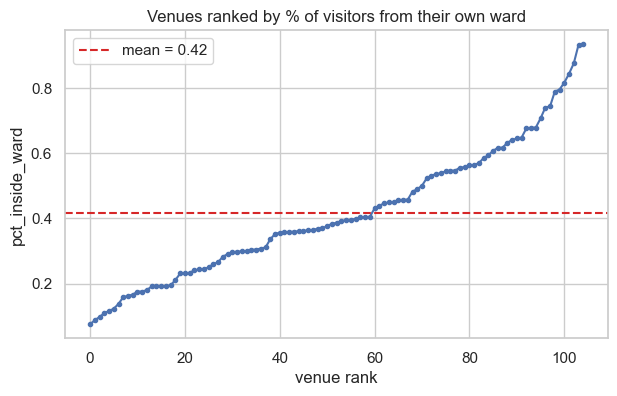

In [20]:
# viz: every venue's pct_inside_ward, sorted -- a "how local is this venue's audience"
# spectrum. If this were a step function (mostly near 0 or near 1) venues would cleanly
# split into "hyper-local" vs. "citywide draw"; a smooth ramp like this instead means most
# venues sit somewhere in between, so that split shouldn't be treated as binary downstream.
_sorted_pct = venue_summary["pct_inside_ward"].sort_values().reset_index(drop=True)

fig, ax = plt.subplots()
ax.plot(_sorted_pct.index, _sorted_pct.values, marker="o", markersize=3, color="#4c72b0")
ax.axhline(_sorted_pct.mean(), color="#d62728", linestyle="--", label=f"mean = {_sorted_pct.mean():.2f}")
ax.set_title("Venues ranked by % of visitors from their own ward")
ax.set_xlabel("venue rank")
ax.set_ylabel("pct_inside_ward")
ax.legend()
plt.show()

## 10. `ward_to_ward_activity`: full (origin ward, destination ward) breakdown

Same idea as `ward_to_venue_activity` in section 9, except the destination is now a ward
(`venue_ward`) instead of an individual venue: group `result` by `(ward_name, venue_ward)`
and sum the interpolated value across every venue that happens to sit in that destination
ward. This answers "how much activity went from ward X to ward Z, across all of Z's
venues combined" -- the piece that was missing before, since the old `ward_to_ward_activity`
only ever reported in/out-of-own-ward totals, not which *other* ward the outside activity
went to.

Like section 6, every (origin, destination) pair is filled in (0.0 if no activity), so this
is a dense 25x25 = 625-row table, and every origin ward's `_pct` column sums to 100% --
mirroring the per-venue `_pct` column in section 9.


In [21]:
all_wards_sorted = sorted(wards_gdf[WARD_NAME_COL].unique())

# collapse venue -> destination ward: sum every venue's contribution into its own ward
ward_to_ward = (
    result.groupby([WARD_NAME_COL, DEST_WARD_COL], as_index=False)[RESULT_COL].sum()
)

# fill in every (origin, destination) pair, including zero-activity ones, so this is a
# dense matrix rather than a sparse "only pairs that happened" table
full_ward_index = pd.MultiIndex.from_product([all_wards_sorted, all_wards_sorted], names=[WARD_NAME_COL, DEST_WARD_COL])
ward_to_ward_activity = pd.DataFrame(index=full_ward_index).reset_index()
ward_to_ward_activity = ward_to_ward_activity.merge(ward_to_ward, on=[WARD_NAME_COL, DEST_WARD_COL], how="left")
ward_to_ward_activity[RESULT_COL] = ward_to_ward_activity[RESULT_COL].fillna(0.0)

ward_to_ward_activity["same_ward"] = ward_to_ward_activity[WARD_NAME_COL] == ward_to_ward_activity[DEST_WARD_COL]

# pct of ORIGIN ward's total -- "of everyone leaving ward X, what % ended up in ward Z"
# (each origin ward's rows sum to 100%, mirroring the per-venue pct in section 9)
PCT_OF_ORIGIN_COL = f"{RESULT_COL}_pct_of_origin"
_origin_totals = ward_to_ward_activity.groupby(WARD_NAME_COL)[RESULT_COL].transform("sum")
ward_to_ward_activity[PCT_OF_ORIGIN_COL] = (ward_to_ward_activity[RESULT_COL] / _origin_totals).fillna(0.0)

# pct of DESTINATION ward's total -- "of everyone arriving in ward Z, what % came from ward X"
PCT_OF_DEST_COL = f"{RESULT_COL}_pct_of_destination"
_dest_totals = ward_to_ward_activity.groupby(DEST_WARD_COL)[RESULT_COL].transform("sum")
ward_to_ward_activity[PCT_OF_DEST_COL] = (ward_to_ward_activity[RESULT_COL] / _dest_totals).fillna(0.0)

print(f"rows: {len(ward_to_ward_activity)}  (should be {len(all_wards_sorted)}^2 = {len(all_wards_sorted) ** 2})")

# sanity checks: (1) grand total should match `result`'s grand total, since we've just
# regrouped the same rows by (origin, destination) instead of (origin, venue); (2) every
# origin ward's pct_of_origin should sum to 1.0 (or 0.0 if that ward sends nothing anywhere)
_total_diff = abs(ward_to_ward_activity[RESULT_COL].sum() - result[RESULT_COL].sum())
print(f"Reconstruction diff vs result total (should be ~0): {_total_diff:.6f}")

_origin_pct_check = ward_to_ward_activity.groupby(WARD_NAME_COL)[PCT_OF_ORIGIN_COL].sum()
_bad_origin = _origin_pct_check[~_origin_pct_check.round(6).isin([0.0, 1.0])]
if len(_bad_origin):
    print(f"WARNING: {len(_bad_origin)} origin ward(s) with pct_of_origin not summing to 0 or 1: {_bad_origin.to_dict()}")

ward_to_ward_activity.to_csv(WARD_TO_WARD_ACTIVITY_CSV, index=False)
ward_to_ward_activity.to_json(WARD_TO_WARD_ACTIVITY_JSON, orient="records", indent=2)

ward_to_ward_activity.sort_values(RESULT_COL, ascending=False).head(20)

rows: 625  (should be 25^2 = 625)
Reconstruction diff vs result total (should be ~0): 0.000000


,ward_name,venue_ward,normalized_raw_stop_count_by_ward,same_ward,normalized_raw_stop_count_by_ward_pct_of_origin,normalized_raw_stop_count_by_ward_pct_of_destination
572,Willowdale,Willowdale,24130.028706,True,0.944701,0.679273
546,University-Rosedale,University-Rosedale,7180.658152,True,0.684440,0.330017
442,Spadina-Fort York,Spadina-Fort York,7158.216057,True,0.516089,0.384968
468,Toronto Centre,Toronto Centre,6683.621709,True,0.534949,0.385179
443,Spadina-Fort York,Toronto Centre,4396.931403,False,0.317008,0.253397
471,Toronto Centre,University-Rosedale,2617.617065,False,0.209511,0.120304
467,Toronto Centre,Spadina-Fort York,2181.203819,False,0.174581,0.117305
122,Don Valley West,Willowdale,1506.799155,False,0.540632,0.042417
542,University-Rosedale,Spadina-Fort York,1471.259209,False,0.140236,0.079124
597,York Centre,Willowdale,1347.726074,False,0.436749,0.037939


## 10b. Per-origin-ward breakdown files (for exploration)

`ward_to_ward_activity` above is already a complete 25x25 table, but for exploring "where
does ward X's activity go" one ward at a time (e.g. eyeballing a CSV, or a quick per-ward
notebook later), it's convenient to also have one small file per origin ward, sorted by
how much activity it sends to each destination. Written to `WARD_BREAKDOWN_DIR`.


In [22]:
WARD_CODE_COL = "ward_code"
_ward_codes = wards_gdf.drop_duplicates(WARD_NAME_COL).set_index(WARD_NAME_COL)[WARD_CODE_COL]

for origin_ward in tqdm(all_wards_sorted, desc="writing per-ward breakdowns"):
    ward_code = _ward_codes.get(origin_ward, origin_ward)
    df_origin = (
        ward_to_ward_activity[ward_to_ward_activity[WARD_NAME_COL] == origin_ward]
        .sort_values(RESULT_COL, ascending=False)
    )
    df_origin.to_csv(os.path.join(WARD_BREAKDOWN_DIR, f"{ward_code}.csv"), index=False)

print(f"Wrote {len(all_wards_sorted)} per-origin-ward files to {WARD_BREAKDOWN_DIR}")

writing per-ward breakdowns:   0%|          | 0/25 [00:00<?, ?it/s]

writing per-ward breakdowns: 100%|██████████| 25/25 [00:00<00:00, 1074.10it/s]

Wrote 25 per-origin-ward files to ../../data/activity/wards/by_origin_ward


## 10c. Ward-to-ward matrix (for heatmaps)

The same data as `ward_to_ward_activity`, pivoted wide: one row per origin ward, one column
per destination ward. Handy for plotting a 25x25 heatmap directly (e.g. `seaborn.heatmap`)
without re-pivoting `ward_to_ward_activity.csv` every time.


In [23]:
ward_to_ward_matrix = ward_to_ward_activity.pivot(index=WARD_NAME_COL, columns=DEST_WARD_COL, values=RESULT_COL)
ward_to_ward_matrix.to_csv(WARD_TO_WARD_MATRIX_CSV)

ward_to_ward_matrix.iloc[:5, :5]

venue_ward,Beaches-East York,Davenport,Don Valley East,Don Valley North,Don Valley West
ward_name,,,,,
Beaches-East York,1252.559473,25.683012,32.699201,8.749879,0.738760
Davenport,7.271516,709.905569,16.846841,4.209865,1.217956
Don Valley East,54.187315,14.398751,177.025540,155.142582,2.215678
Don Valley North,12.203109,17.929871,25.825027,1346.057175,4.207489
Don Valley West,22.641755,19.179292,17.459795,30.797764,5.607027


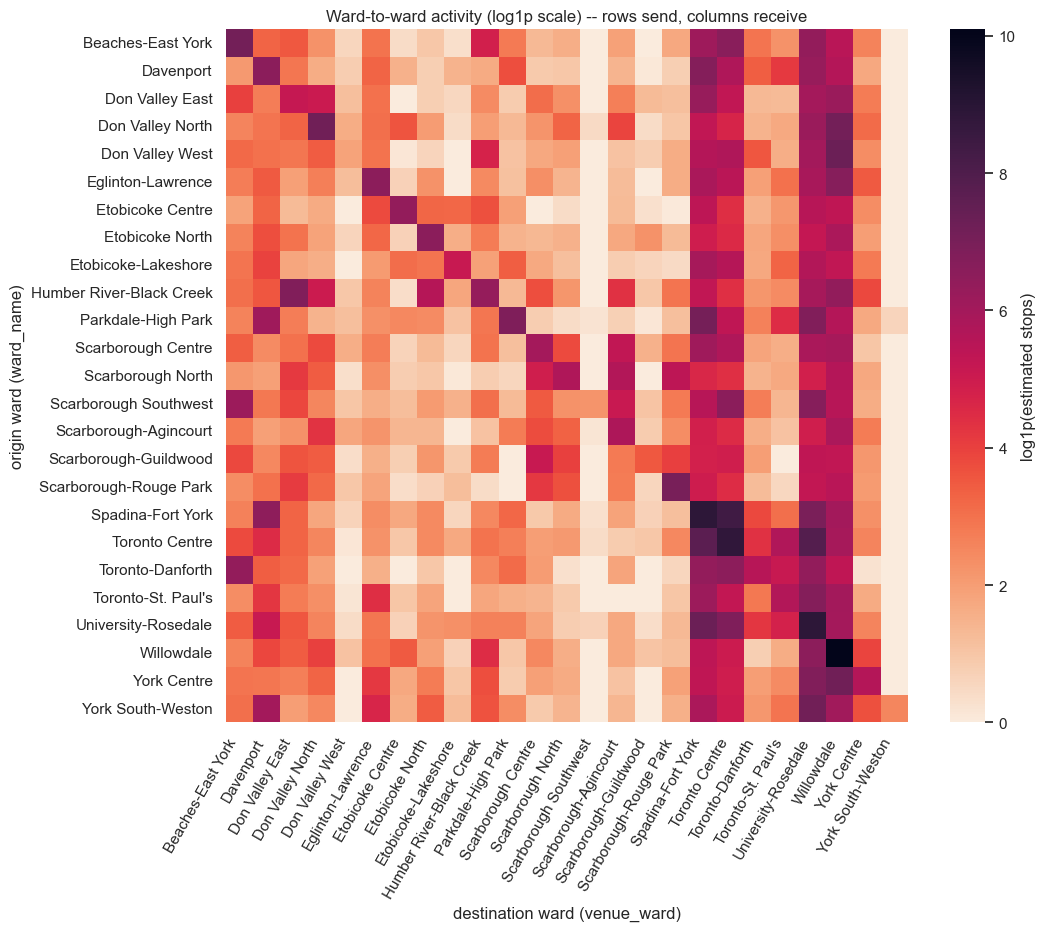

In [24]:
import numpy as np

# viz: the full 25x25 ward-to-ward flow, log-scaled -- the diagonal (within-ward activity)
# is consistently the brightest cell in its row, confirming that "stay local" dominates,
# but the off-diagonal brightness varies a lot by column: some destination wards (e.g. the
# downtown-core ones) pull noticeably from many origins, others barely register outside
# their own row/column. log1p keeps the small flows visible next to the large ones.
fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(np.log1p(ward_to_ward_matrix), cmap="rocket_r", cbar_kws={"label": "log1p(estimated stops)"}, ax=ax)
ax.set_title("Ward-to-ward activity (log1p scale) -- rows send, columns receive")
ax.set_xlabel("destination ward (venue_ward)")
ax.set_ylabel("origin ward (ward_name)")
plt.xticks(rotation=60, ha="right")
plt.show()

## 11. `ward_to_ward_summary`: in vs. out of each origin ward

Rolls `ward_to_ward_activity` up further, from a full 25x25 breakdown to one row per origin
ward, using `same_ward` to split each origin ward's total into:

- **within_ward** -- activity that stayed in the same ward (`same_ward == True`)
- **outside_ward** -- activity that went to any *other* ward (`same_ward == False`)
- **pct_inside_ward** / **pct_outside_ward** -- that split as a % of the ward's own total

This is what the old `ward_to_ward_activity` file used to be -- kept as a coarser companion
to the new, full breakdown above, for whenever only the in/out split is needed.


In [25]:
within_ward = ward_to_ward_activity[ward_to_ward_activity["same_ward"]].set_index(WARD_NAME_COL)[RESULT_COL]
outside_ward = ward_to_ward_activity[~ward_to_ward_activity["same_ward"]].groupby(WARD_NAME_COL)[RESULT_COL].sum()

WITHIN_COL = f"{VALUE_COL}_within_ward"
OUTSIDE_COL = f"{VALUE_COL}_outside_ward"

ward_to_ward_summary = pd.DataFrame({WARD_NAME_COL: all_wards_sorted}).set_index(WARD_NAME_COL)
ward_to_ward_summary[WITHIN_COL] = within_ward
ward_to_ward_summary[OUTSIDE_COL] = outside_ward
ward_to_ward_summary = ward_to_ward_summary.fillna(0.0).reset_index()

# additional columns: what % of THIS ward's total (within + outside) stayed inside vs left --
# a ward with zero activity either way gets 0.0/0.0 rather than a NaN from dividing by zero
PCT_WITHIN_COL = "pct_inside_ward"
PCT_OUTSIDE_COL = "pct_outside_ward"
_ward_totals = ward_to_ward_summary[WITHIN_COL] + ward_to_ward_summary[OUTSIDE_COL]
ward_to_ward_summary[PCT_WITHIN_COL] = (ward_to_ward_summary[WITHIN_COL] / _ward_totals).fillna(0.0)
ward_to_ward_summary[PCT_OUTSIDE_COL] = (ward_to_ward_summary[OUTSIDE_COL] / _ward_totals).fillna(0.0)

# sanity check: within + outside across all wards should equal the grand total in `result`
total_diff = abs(ward_to_ward_summary[[WITHIN_COL, OUTSIDE_COL]].sum().sum() - result[RESULT_COL].sum())
print(f"Reconstruction diff vs result total (should be ~0): {total_diff:.6f}")

ward_to_ward_summary.to_csv(WARD_TO_WARD_SUMMARY_CSV, index=False)
ward_to_ward_summary.to_json(WARD_TO_WARD_SUMMARY_JSON, orient="records", indent=2)
ward_to_ward_summary.sort_values(WITHIN_COL, ascending=False).head(20)

Reconstruction diff vs result total (should be ~0): 0.000000


,ward_name,normalized_raw_stop_count_within_ward,normalized_raw_stop_count_outside_ward,pct_inside_ward,pct_outside_ward
22,Willowdale,24130.028706,1412.476612,0.944701,0.055299
21,University-Rosedale,7180.658152,3310.638490,0.684440,0.315560
17,Spadina-Fort York,7158.216057,6711.889957,0.516089,0.483911
18,Toronto Centre,6683.621709,5810.309239,0.534949,0.465051
3,Don Valley North,1346.057175,2301.043370,0.369076,0.630924
0,Beaches-East York,1252.559473,2306.476198,0.351938,0.648062
16,Scarborough-Rouge Park,1099.847255,923.711374,0.543521,0.456479
10,Parkdale-High Park,926.461924,3206.210046,0.224180,0.775820
7,Etobicoke North,717.423405,921.774416,0.437667,0.562333
1,Davenport,709.905569,2152.282030,0.248029,0.751971


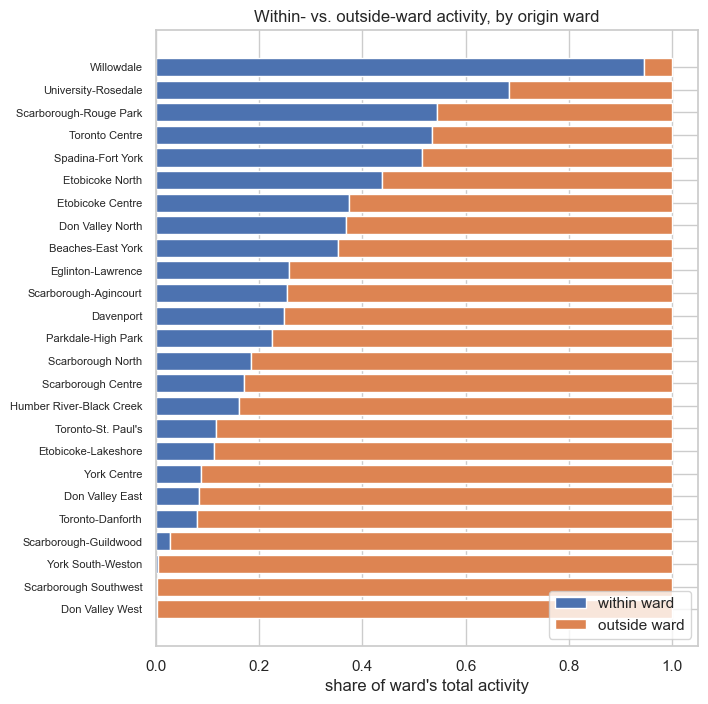

In [26]:
# viz: every ward's within- vs. outside-ward split, sorted by how self-contained it is --
# a wide spread here (rather than every ward clustering near the same split) means "ward"
# alone doesn't determine local-vs-citywide draw; something ward-specific (e.g. how many/
# what kind of venues it has) is driving the variation, which matters for interpreting any
# ward-level demographic correlation later.
_sorted_summary = ward_to_ward_summary.sort_values("pct_inside_ward", ascending=True)

fig, ax = plt.subplots(figsize=(7, 8))
y = range(len(_sorted_summary))
ax.barh(y, _sorted_summary["pct_inside_ward"], color="#4c72b0", label="within ward")
ax.barh(y, _sorted_summary["pct_outside_ward"], left=_sorted_summary["pct_inside_ward"], color="#dd8452", label="outside ward")
ax.set_yticks(list(y))
ax.set_yticklabels(_sorted_summary[WARD_NAME_COL], fontsize=8)
ax.set_xlabel("share of ward's total activity")
ax.set_title("Within- vs. outside-ward activity, by origin ward")
ax.legend(loc="lower right")
plt.show()

## 12. Stage-by-stage total (find exactly where a number changes)

Prints the sum of the interpolated value at each stage of the pipeline. Every number here
should be identical unless duplication or overlap is happening -- if one line jumps up from
the line above it, that's the exact stage to investigate (using the warnings printed earlier
in that stage's cell).


In [27]:
_raw_unfiltered = pd.read_csv(VENUES_HOMES_CSV)
_raw_unfiltered_sum = _raw_unfiltered[VALUE_COL].sum()
_raw_filtered_sum = (
    _raw_unfiltered[_raw_unfiltered[TIME_PERIOD_COL] == TIME_PERIOD_VALUE][VALUE_COL].sum()
    if TIME_PERIOD_COL in _raw_unfiltered.columns else _raw_unfiltered_sum
)
_post_merge_sum = venues_homes[VALUE_COL].sum()
_grid_sum = grid_gdf[VALUE_COL].sum()
_ward_venue_agg_sum = ward_venue_agg[RESULT_COL].sum()
_result_sum = result[RESULT_COL].sum()
_ward_to_ward_activity_sum = ward_to_ward_activity[RESULT_COL].sum()
_ward_to_ward_summary_sum = ward_to_ward_summary[[WITHIN_COL, OUTSIDE_COL]].sum().sum()

print(f"{'raw venues_homes.csv sum (unfiltered, all time_periods):':58s} {_raw_unfiltered_sum:,.3f}")
print(f"{f'raw sum after filtering to time_period==\'{TIME_PERIOD_VALUE}\':':58s} {_raw_filtered_sum:,.3f}   <- everything below should match this, not the line above")
print(f"{'venues_homes post-merge sum:':58s} {_post_merge_sum:,.3f}")
print(f"{'grid_gdf sum:':58s} {_grid_sum:,.3f}")
print(f"{'ward_venue_agg sum (post-overlay):':58s} {_ward_venue_agg_sum:,.3f}")
print(f"{'result sum (ward_to_venue_activity, post fill-0):':58s} {_result_sum:,.3f}")
print(f"{'ward_to_ward_activity sum (post fill-0):':58s} {_ward_to_ward_activity_sum:,.3f}")
print(f"{'ward_to_ward_summary sum (within+outside):':58s} {_ward_to_ward_summary_sum:,.3f}")

raw venues_homes.csv sum (unfiltered, all time_periods):   302,370.771
raw sum after filtering to time_period=='all':             116,008.002   <- everything below should match this, not the line above
venues_homes post-merge sum:                               116,008.002
grid_gdf sum:                                              116,008.002
ward_venue_agg sum (post-overlay):                         115,058.240
result sum (ward_to_venue_activity, post fill-0):          115,058.240
ward_to_ward_activity sum (post fill-0):                   115,058.240
ward_to_ward_summary sum (within+outside):                 115,058.240
